<a href="https://colab.research.google.com/github/GabrielaCordeiro0/GabrielaCordeiro0/blob/main/Cont_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import re
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

#Dados - Leitura e Analises Iniciais

In [ ]:
# 1. Fazer upload dos arquivos JSON manualmente no Google Colab
from google.colab import files

uploaded = files.upload()

Saving part-00000-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json to part-00000-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json
Saving part-00001-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json to part-00001-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json
Saving part-00002-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json to part-00002-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json
Saving part-00003-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json to part-00003-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json
Saving part-00004-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json to part-00004-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json
Saving part-00005-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json to part-00005-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json
Saving part-00006-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json to part-00006-6d146842-4148-45d2-970f-ec0f3f30efa6-c000.json


In [ ]:
# 2. Listar os arquivos JSON enviados
json_files = list(uploaded.keys())



In [ ]:
 #3. Carregar e unificar os arquivos JSON
dataframes = []

for file in json_files:
    with open(file, 'r', encoding='utf-8') as f:
        try:
            data = [json.loads(line) for line in f]  # Lê cada linha separadamente
            df = pd.json_normalize(data)  # Converte para DataFrame
            dataframes.append(df)
        except json.JSONDecodeError:
            print(f"Erro ao carregar {file}: o JSON pode estar mal formatado.")


In [ ]:
# 4. Concatenar todos os DataFrames em um só, se houver dados
if dataframes:
    df_final = pd.concat(dataframes, ignore_index=True)
    print("Arquivos NDJSON unificados com sucesso!")
    display(df_final.head())  # Exibir as primeiras linhas do DataFrame final
else:
    print("Nenhum arquivo foi carregado corretamente.")

Arquivos NDJSON unificados com sucesso!


,usuario,produto,genero,idade,produto_categoria,valor,estado_civil
0,1000001,P00069042,F,0-17,3,8370,0
1,1000001,P00248942,F,0-17,1,15200,0
2,1000001,P00087842,F,0-17,12,1422,0
3,1000001,P00085442,F,0-17,12,1057,0
4,1000002,P00285442,M,55+,8,7969,0


In [ ]:
# Verificar informações das colunas
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   usuario            550068 non-null  object
 1   produto            550068 non-null  object
 2   genero             550068 non-null  object
 3   idade              550068 non-null  object
 4   produto_categoria  550068 non-null  object
 5   valor              550068 non-null  object
 6   estado_civil       550068 non-null  object
dtypes: object(7)
memory usage: 29.4+ MB


In [ ]:
# Ver estatísticas básicas das colunas numéricas
df_final.describe()

,usuario,produto,genero,idade,produto_categoria,valor,estado_civil
count,550068,550068,550068,550068,550068,550068,550068
unique,5891,3631,2,7,20,18105,2
top,1001680,P00265242,M,26-35,5,7011,0
freq,1026,1880,414259,219587,150933,191,324731


In [ ]:
# Checando se há valores missing
df_final.isnull().values.any()

np.False_

# Criando ambiente PySPARK

In [ ]:
from pyspark.sql import SparkSession

# Criar uma sessão do Spark
spark = SparkSession.builder.appName("MeuAppPySpark").getOrCreate()

In [ ]:
df_spark = spark.createDataFrame(df_final)
df_spark.show(5)  # Exibir as 5 primeiras linhas

+-------+---------+------+-----+-----------------+-----+------------+
|usuario|  produto|genero|idade|produto_categoria|valor|estado_civil|
+-------+---------+------+-----+-----------------+-----+------------+
|1000001|P00069042|     F| 0-17|                3| 8370|           0|
|1000001|P00248942|     F| 0-17|                1|15200|           0|
|1000001|P00087842|     F| 0-17|               12| 1422|           0|
|1000001|P00085442|     F| 0-17|               12| 1057|           0|
|1000002|P00285442|     M|  55+|                8| 7969|           0|
+-------+---------+------+-----+-----------------+-----+------------+
only showing top 5 rows



In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg , sum, count, format_number

In [ ]:
# 01- Qual o ticket médio das vendas por idade ordenado por idade?
df_ticket_medio = (
    df_spark.groupBy("idade")
    .agg(format_number(avg(col("valor")), 2).alias("ticket_medio"))
    .orderBy("idade")
)

# Exibir o resultado
df_ticket_medio.show()

+-----+------------+
|idade|ticket_medio|
+-----+------------+
| 0-17|    8,933.46|
|18-25|    9,169.66|
|26-35|    9,252.69|
|36-45|    9,331.35|
|46-50|    9,208.63|
|51-55|    9,534.81|
|  55+|    9,336.28|
+-----+------------+



In [ ]:
#2 - Qual o total de vendas por idade ordenado pelo valor total de vendas?

df_total_vendas = (
    df_spark.groupBy("idade")
    .agg(sum(col("valor")).alias("total_vendas"))
    .orderBy(col("total_vendas"), ascending=False)  # Ordenando pelo total de vendas, do maior para o menor
)

# Exibir o resultado
df_total_vendas.show()

+-----+-------------+
|idade| total_vendas|
+-----+-------------+
|26-35|2.031770578E9|
|36-45|1.026569884E9|
|18-25| 9.13848675E8|
|46-50| 4.20843403E8|
|51-55| 3.67099644E8|
|  55+| 2.00767375E8|
| 0-17| 1.34913183E8|
+-----+-------------+



In [ ]:
#3 - Liste a quantidade dos 10 produtos mais vendidos
df_top10_produtos = (
    df_spark.groupBy("produto")  # Agrupa pelo nome do produto
    .agg(sum(col("valor")).alias("total_vendas"))  # Soma o valor das vendas por produto
    .orderBy(col("total_vendas"), ascending=False)  # Ordena de forma decrescente
    .limit(10)  # Limita para os 10 mais vendidos
)

# Exibir o resultado
df_top10_produtos.show()

+---------+------------+
|  produto|total_vendas|
+---------+------------+
|P00025442| 2.7995166E7|
|P00110742| 2.6722309E7|
|P00255842| 2.5168963E7|
|P00059442| 2.4338343E7|
|P00184942| 2.4334887E7|
|P00112142| 2.4216006E7|
|P00110942| 2.3639564E7|
|P00237542| 2.3425576E7|
|P00057642|  2.310278E7|
|P00010742| 2.2164153E7|
+---------+------------+



In [ ]:
# 4 - Quantos usuários únicos existem na base?

num_usuarios_unicos = df_spark.select("usuario").distinct().count()

# Exibir o resultado
print(f"Quantidade de usuários únicos: {num_usuarios_unicos}")

Quantidade de usuários únicos: 5891


In [ ]:
#5 - Liste os 10 usuários com o maior valor total de vendas
#Como não tem col de quantidade , vou usar o valor total de vendas para determinar quais produtos foram mais vendidos. Ou seja, vou considerar que quanto maior o valor total de vendas , maior a quantidade de produtos vendidos.
df_top10_usuarios = (
    df_spark.groupBy("usuario")  # Agrupa pelos usuários
    .agg(sum(col("valor")).alias("total_vendas"))  # Soma o valor das vendas por usuário
    .orderBy(col("total_vendas"), ascending=False)  # Ordena do maior para o menor valor de vendas
    .limit(10)  # Limita para os 10 maiores valores
)

# Exibir o resultado
df_top10_usuarios.show()

+-------+------------+
|usuario|total_vendas|
+-------+------------+
|1004277| 1.0536909E7|
|1001680|   8699596.0|
|1002909|   7577756.0|
|1001941|   6817493.0|
|1000424|   6573609.0|
|1004448|   6566245.0|
|1005831|   6512433.0|
|1001015|   6511314.0|
|1003391|   6477160.0|
|1001181|   6387961.0|
+-------+------------+



In [ ]:
#6 - Qual porcentagem representa cada faixa etária da base de usuários únicos?
df_usuarios_por_idade = (
    df_spark.select("usuario", "idade")  # Seleciona usuário e faixa etária
    .distinct()  # Garante que são usuários únicos por faixa etária
    .groupBy("idade")  # Agrupa por faixa etária
    .count()  # Conta o número de usuários por faixa etária
)

# Calcular a porcentagem para cada faixa etária
df_porcentagem_faixa_etaria = df_usuarios_por_idade.withColumn(
    "porcentagem", (col("count") / num_usuarios_unicos) * 100
)

# Exibir o resultado
df_porcentagem_faixa_etaria.show()

+-----+-----+------------------+
|idade|count|       porcentagem|
+-----+-----+------------------+
|18-25| 1069| 18.14632490239348|
|26-35| 2053|  34.8497708368698|
| 0-17|  218|3.7005601765404856|
|46-50|  531| 9.013749787811918|
|51-55|  481| 8.164997453742998|
|36-45| 1167| 19.80987947716856|
|  55+|  372| 6.314717365472755|
+-----+-----+------------------+



# 2 PARTE

1 - A empresa precisa identificar qual o público que teve mais alcance na Black Friday, para que no próximo ano tenha uma campanha mais direcionada. Considerando o ticket médio como resultado, faça uma análise e descreva qual ou quais as variáveis mais importantes. Considere: estado civil, gênero, idade, produto e categoria do produto e descreva o racional.

In [ ]:
# Criar uma visão geral do ticket médio por diferentes variáveis

# Ticket médio por estado civil
df_ticket_estado_civil = (
    df_spark.groupBy("estado_civil")
    .agg(avg(col("valor")).alias("ticket_medio"))
    .orderBy(col("ticket_medio"), ascending=False)
)

# Ticket médio por gênero
df_ticket_genero = (
    df_spark.groupBy("genero")
    .agg(avg(col("valor")).alias("ticket_medio"))
    .orderBy(col("ticket_medio"), ascending=False)
)

# Ticket médio por idade
df_ticket_idade = (
    df_spark.groupBy("idade")
    .agg(avg(col("valor")).alias("ticket_medio"))
    .orderBy(col("ticket_medio"), ascending=False)
)


# Ticket médio por categoria de produto
df_ticket_categoria = (
    df_spark.groupBy("produto_categoria")
    .agg(avg(col("valor")).alias("ticket_medio"))
    .orderBy(col("ticket_medio"), ascending=False)
)

# Exibir os resultados
df_ticket_estado_civil.show()
df_ticket_genero.show()
df_ticket_idade.show()
df_ticket_categoria.show()


+------------+-----------------+
|estado_civil|     ticket_medio|
+------------+-----------------+
|           0|9265.907618921507|
|           1|9261.174574082374|
+------------+-----------------+

+------+-----------------+
|genero|     ticket_medio|
+------+-----------------+
|     M|9437.526040472265|
|     F|8734.565765155476|
+------+-----------------+

+-----+-----------------+
|idade|     ticket_medio|
+-----+-----------------+
|51-55|9534.808030960236|
|  55+|9336.280459449405|
|36-45|9331.350694917874|
|26-35|9252.690632869888|
|46-50|9208.625697468327|
|18-25|9169.663606261289|
| 0-17|8933.464640444974|
+-----+-----------------+

+-----------------+------------------+
|produto_categoria|      ticket_medio|
+-----------------+------------------+
|               10|19675.570926829267|
|                7|16365.689599570009|
|                6|15838.478549789896|
|                9|15537.375609756098|
|               15|14780.451828298887|
|               16|14766.037037037036|


Análise das Variáveis ​​Mais Importantes

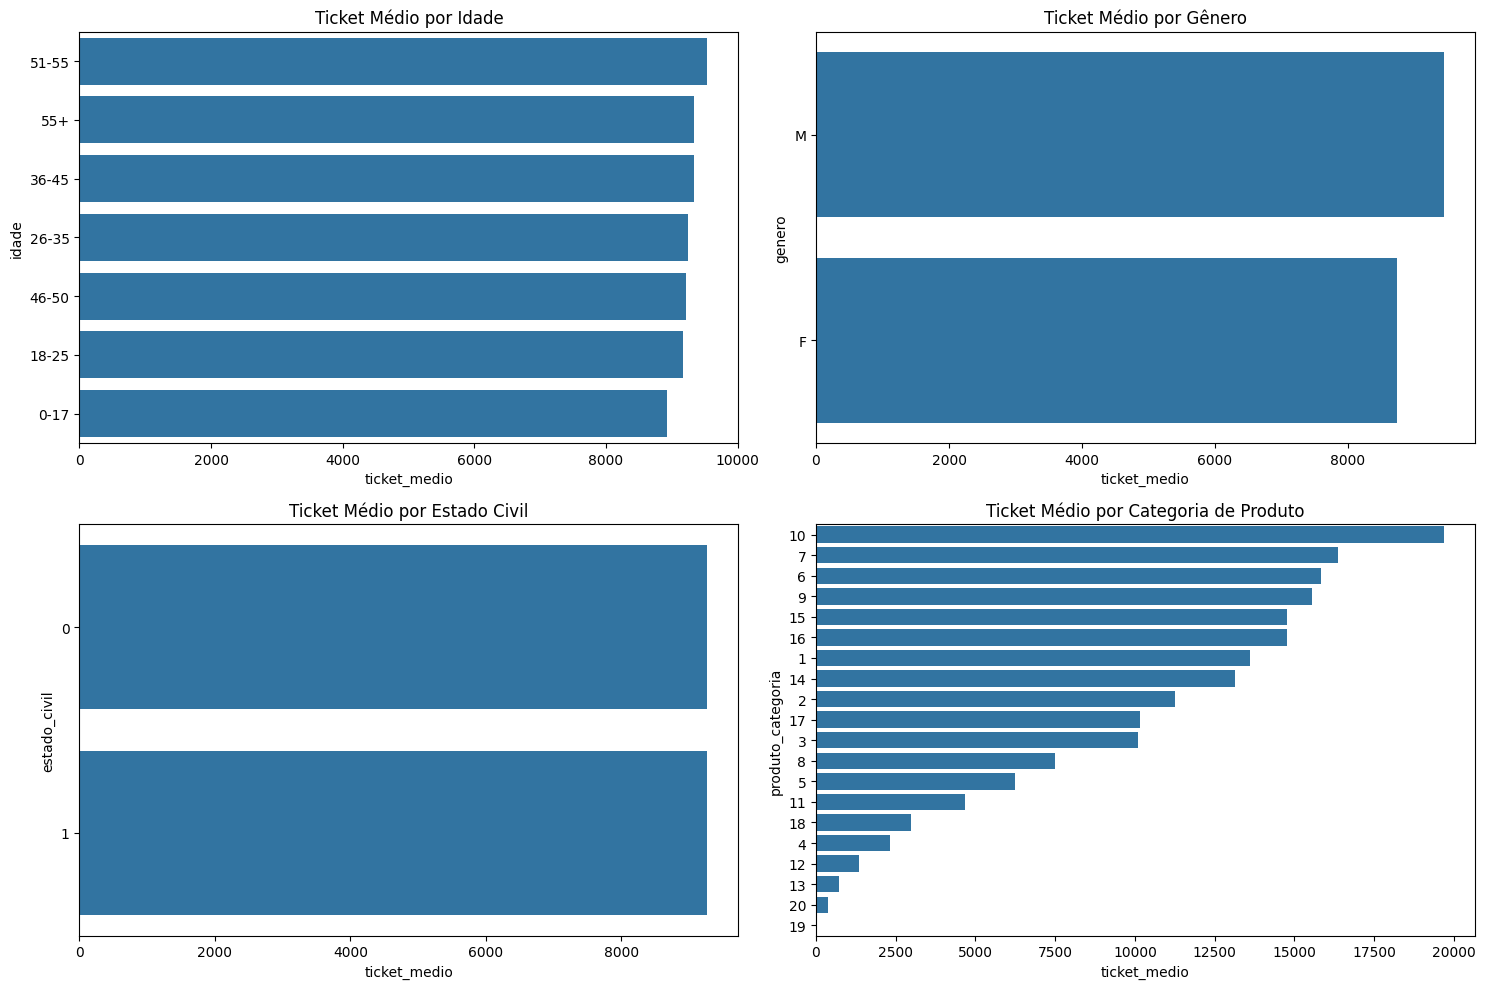

In [ ]:

# Função para calcular o ticket médio por variável e converter para Pandas
def calcular_ticket_medio(df, coluna):
    df_result = (
        df_spark.groupBy(coluna)
        .agg((sum(col("valor")) / count("*")).alias("ticket_medio"))
        .orderBy(col("ticket_medio"), ascending=False)
    )
    return df_result.toPandas()

# Calcular ticket médio por diferentes variáveis
df_ticket_idade = calcular_ticket_medio(df, "idade")
df_ticket_genero = calcular_ticket_medio(df, "genero")
df_ticket_estado_civil = calcular_ticket_medio(df, "estado_civil")
df_ticket_categoria = calcular_ticket_medio(df, "produto_categoria")

# Criar uma figura com subgráficos
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plotar cada gráfico
sns.barplot(x="ticket_medio", y="idade", data=df_ticket_idade, ax=axes[0,0])
axes[0,0].set_title("Ticket Médio por Idade")

sns.barplot(x="ticket_medio", y="genero", data=df_ticket_genero, ax=axes[0,1])
axes[0,1].set_title("Ticket Médio por Gênero")

sns.barplot(x="ticket_medio", y="estado_civil", data=df_ticket_estado_civil, ax=axes[1,0])
axes[1,0].set_title("Ticket Médio por Estado Civil")

sns.barplot(x="ticket_medio", y="produto_categoria", data=df_ticket_categoria, ax=axes[1,1])
axes[1,1].set_title("Ticket Médio por Categoria de Produto")

# Ajustar layout
plt.tight_layout()
plt.show()


Conclusão e Estratégia para a Próxima Black Friday

- Foco nos públicos de maior ticket médio : Investir orçamento em anúncios direcionados para as faixas etárias, gênero e categoria. (estado civil não tem relação significativa)
- Otimização de produtos e categorias : Crie campanhas específicas para os produtos com maior ticket médio.
- Personalização da comunicação : Utilize segmentação para oferecer descontos, brindes ou ofertas especiais para o público mais lucrativo.

2- Além do público-alvo, a empresa precisa também analisar as saídas por categoria de produto. Favorecer analisar e demonstrar o racional e um gráfico.

<ipython-input-39-3af45bd0d9f8>:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="ticket_medio", y="produto_categoria", data=df_ticket_categoria_pd, palette="viridis")


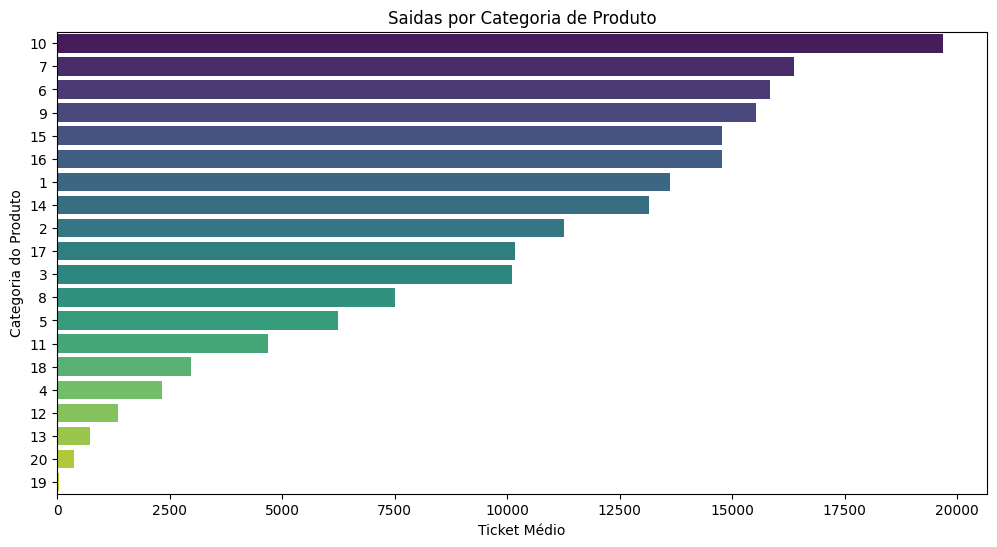

In [ ]:
# Calcular o ticket médio por categoria
df_ticket_categoria = (
    df_spark.groupBy("produto_categoria")
    .agg((sum("valor") / count("*")).alias("ticket_medio"))
    .orderBy("ticket_medio", ascending=False)
)

# Converter para Pandas para visualização
df_ticket_categoria_pd = df_ticket_categoria.toPandas()

# Criar gráfico de barras para visualizar o ticket médio por categoria de produto
plt.figure(figsize=(12, 6))
sns.barplot(x="ticket_medio", y="produto_categoria", data=df_ticket_categoria_pd, palette="viridis")
plt.xlabel("Ticket Médio")
plt.ylabel("Categoria do Produto")
plt.title("Saidas por Categoria de Produto")
plt.show()


<ipython-input-42-4eb2973e8215>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_vendas", y="produto_categoria", data=df_ticket_categoria_pd, palette="viridis")


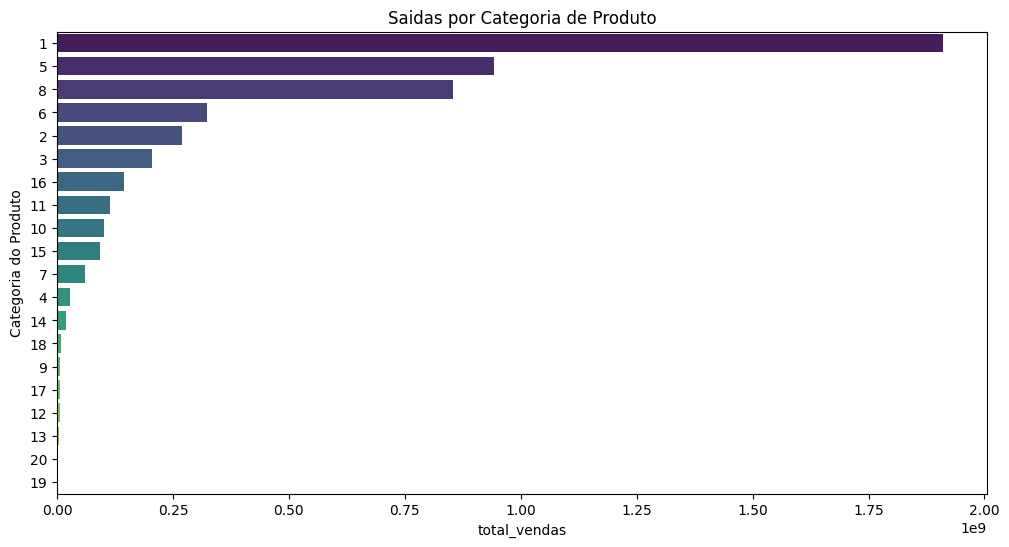

In [ ]:
# Calcular a quantidade de vendas por categoria ( abordagem por "total de vendas")

df_ticket_categoria = (
    df_spark.groupBy("produto_categoria")
    .agg(sum(col("valor")).alias("total_vendas"))
    .orderBy(col("total_vendas"), ascending=False)

)

# Converter para Pandas para visualização
df_ticket_categoria_pd = df_ticket_categoria.toPandas()

# Criar gráfico de barras para visualizar o ticket médio por categoria de produto
plt.figure(figsize=(12, 6))
sns.barplot(x="total_vendas", y="produto_categoria", data=df_ticket_categoria_pd, palette="viridis")
plt.xlabel("total_vendas")
plt.ylabel("Categoria do Produto")
plt.title("Saidas por Categoria de Produto")
plt.show()

03- Dando continuidade na pesquisa para o próximo ano, favor indicar os top 3 produtos que indicaria para venda no próximo ano, e 1 para riscar da lista. Descreva o racional

Racional:

1- O ticket médio dos produtos → Produtos com alto valor médio podem ser estratégicos.

2️- Os produtos mais vendidos → Para manter na lista.

3️- A saída por categoria → Para entender a demanda geral.

4️-  Produtos possíveis com baixo desempenho → Produtos com pouca saída ou ticket médio baixo podem ser retirados.

<ipython-input-43-603a94115670>:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_vendas", y="produto", data=df_top_produtos_pd, ax=axes[0,0], palette="Blues_r")
<ipython-input-43-603a94115670>:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="ticket_medio", y="produto", data=df_top_ticket_pd, ax=axes[0,1], palette="Greens_r")
<ipython-input-43-603a94115670>:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_vendas", y="produto", data=df_produto_menos_vendido_pd, ax=axes[1,0], palette="Reds_r")
<ipython-input-43-603a94115

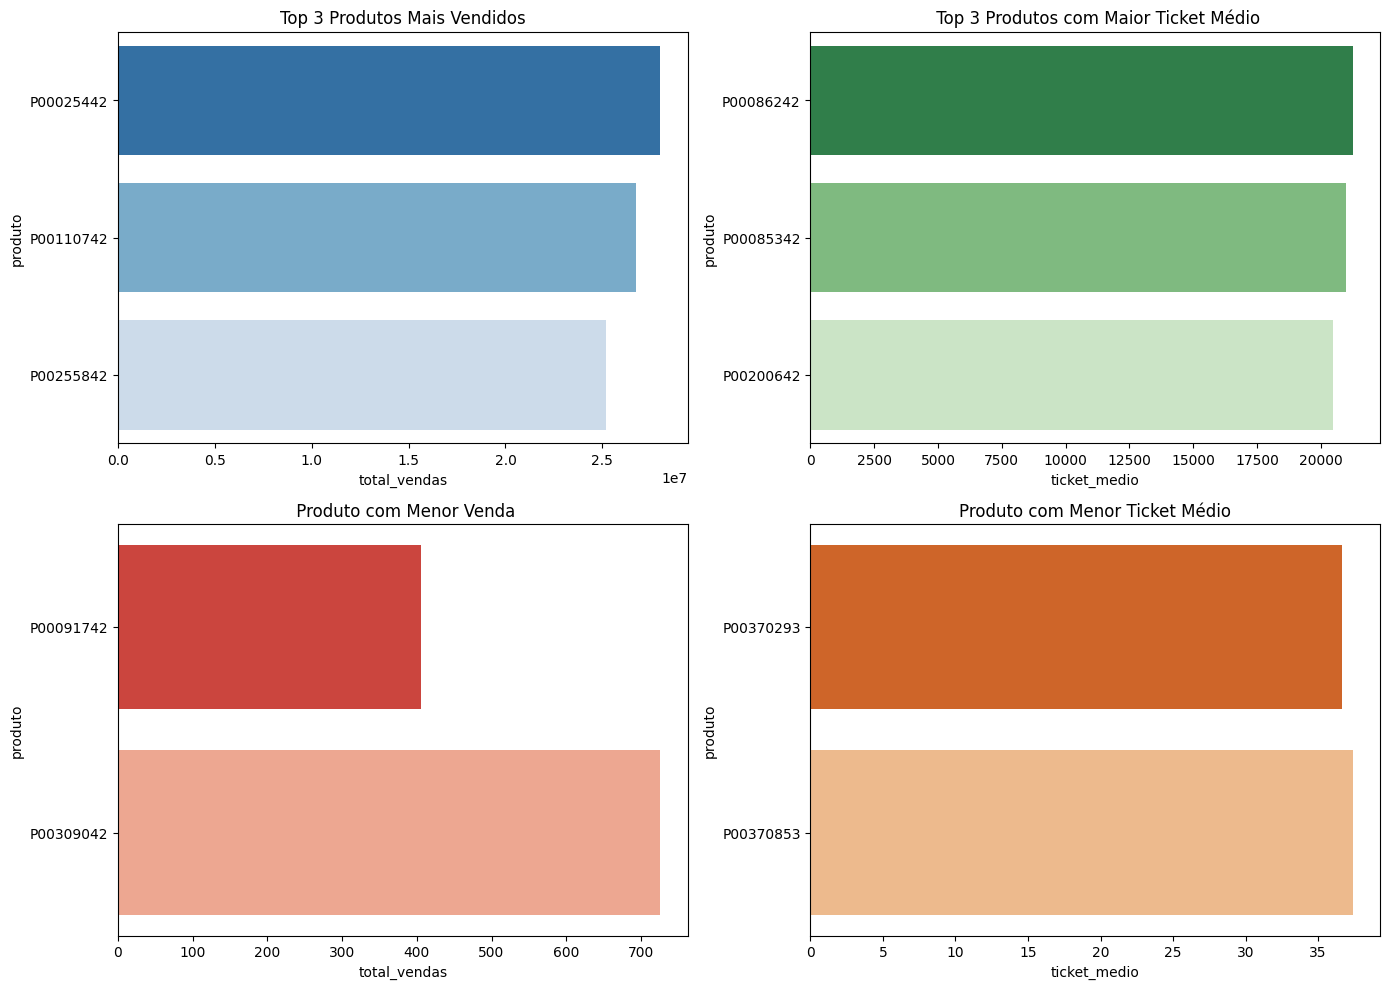

In [ ]:
# Top 3 produtos mais vendidos
df_top_produtos = (
    df_spark.groupBy("produto")
    .agg(sum(col("valor")).alias("total_vendas"))
    .orderBy(col("total_vendas"), ascending=False)
    .limit(3)
)
# Top 3 produtos com maior ticket médio
df_top_ticket = (
    df_spark.groupBy("produto")
    .agg((sum("valor") / count("*")).alias("ticket_medio"))
    .orderBy(col("ticket_medio"), ascending=False)
    .limit(3)
)


#  Produto com menor quantidade de vendas (para remoção)
df_produto_menos_vendido = (
    df_spark.groupBy("produto")
    .agg(sum(col("valor")).alias("total_vendas"))
    .orderBy(col("total_vendas"), ascending=True)
    .limit(2)
)


# Produto com menor ticket médio (para remoção)
df_produto_menor_ticket = (
    df_spark.groupBy("produto")
    .agg((sum("valor") / count("*")).alias("ticket_medio"))
    .orderBy(col("ticket_medio"), ascending=True)
    .limit(2)
)

# Converter para Pandas
df_top_produtos_pd = df_top_produtos.toPandas()
df_top_ticket_pd = df_top_ticket.toPandas()
df_produto_menos_vendido_pd = df_produto_menos_vendido.toPandas()
df_produto_menor_ticket_pd = df_produto_menor_ticket.toPandas()

#  Criar os gráficos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top 3 Produtos Mais Vendidos
sns.barplot(x="total_vendas", y="produto", data=df_top_produtos_pd, ax=axes[0,0], palette="Blues_r")
axes[0,0].set_title("Top 3 Produtos Mais Vendidos")

#  Top 3 Produtos com Maior Ticket Médio
sns.barplot(x="ticket_medio", y="produto", data=df_top_ticket_pd, ax=axes[0,1], palette="Greens_r")
axes[0,1].set_title(" Top 3 Produtos com Maior Ticket Médio")

#  Produto com Menor Quantidade de Vendas
sns.barplot(x="total_vendas", y="produto", data=df_produto_menos_vendido_pd, ax=axes[1,0], palette="Reds_r")
axes[1,0].set_title(" Produto com Menor Venda")

#  Produto com Menor Ticket Médio
sns.barplot(x="ticket_medio", y="produto", data=df_produto_menor_ticket_pd, ax=axes[1,1], palette="Oranges_r")
axes[1,1].set_title("Produto com Menor Ticket Médio")

# Ajustar layout
plt.tight_layout()
plt.show()


In [ ]:
# Converter para Pandas para visualização

df_top_produtos_pd = df_top_produtos.toPandas()
df_top_ticket_pd = df_top_ticket.toPandas()
df_produto_menos_vendido_pd = df_produto_menos_vendido.toPandas()
df_produto_menor_ticket_pd = df_produto_menor_ticket.toPandas()

print("Top 3 Produtos para a Próxima Black Friday:")
print(df_top_ticket_pd )

print("\nProduto para Remover da Lista:")
print(df_produto_menor_ticket_pd)

Top 3 Produtos para a Próxima Black Friday:
     produto  ticket_medio
0  P00086242  21256.505495
1  P00085342  20980.268116
2  P00200642  20468.773234

Produto para Remover da Lista:
     produto  ticket_medio
0  P00370293     36.675159
